In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from results_utils import load_results, aggregate_results

sns.set_theme(style="whitegrid")

GRAPHS = ["Gwps40", "Gwps60"]
GEOM_BASE = "../results/boundary_tracking_gwps_geometry"
GEOM_FOLDER = {"Gwps40": "gwps_n40_ws3", "Gwps60": "gwps_n60_ws3"}
# CBO-U / CBO-U-Geo ran with a different n_int than CBO/Random, and it differs
# by graph size (Gwps40 used n_int=2, Gwps60 used n_int=1)
CBOU_SUFFIX = {"Gwps40": "200_2", "Gwps60": "200_1"}
BASE_SUFFIX = "200_1"
EPS_FRAC = 0.01  # boundary collar width, as a fraction of each variable's intervention range
PDF_DIR = "PDFs"
os.makedirs(PDF_DIR, exist_ok=True)

# label -> (filename stem, color, drop_first)
# drop_first trims CBO's extra leading Best_Y point (Best_Y only; Per_trial_Y is aligned)
METHODS = {
    "CBO-U": ("cbo_unknown_dr2_results", "red", False),
    "CBO": ("cbo_results", "black", True),
    "Random": ("cbo_results_random", "green", False),
}


def curve(results, experiment, drop_first=False):
    mean, std = aggregate_results(results, experiment)
    if drop_first and experiment == "Best_Y":
        mean, std = mean[1:], std[1:]
    return mean, std


def geom_source(graph):
    return f"{GEOM_BASE}/{GEOM_FOLDER[graph]}", rf".*_cbo_unknown_dr2_boundary_EI_{CBOU_SUFFIX[graph]}.pickle"


def method_regex(stem, graph):
    suffix = CBOU_SUFFIX[graph] if stem == "cbo_unknown_dr2_results" else BASE_SUFFIX
    return rf".*_{stem}_{suffix}.pickle"


def _plot_on_ax(ax, graph, experiment):
    gbase, gregex = geom_source(graph)
    mean, std = curve(load_results(gbase, gregex), experiment)
    x = range(len(mean))
    ax.fill_between(x, mean - std, mean + std, alpha=0.2, color="purple")
    ax.plot(x, mean, label="CBO-U-Geo", color="purple", linewidth=2)

    for label, (stem, color, drop_first) in METHODS.items():
        mean, std = curve(load_results(f"../results/{graph}", method_regex(stem, graph)),
                          experiment, drop_first)
        x = range(len(mean))
        ax.fill_between(x, mean - std, mean + std, alpha=0.2, color=color)
        ax.plot(x, mean, label=label, color=color, linewidth=2)

    ax.set_xlabel("Trial")
    ax.set_ylabel(experiment)
    ax.grid(True)
    ax.legend()


def _show(fig, pdf_name):
    fig.tight_layout()
    fig.savefig(f"{PDF_DIR}/{pdf_name}.pdf", bbox_inches="tight")
    display(fig)
    plt.close(fig)


def plot_experiment(experiment):
    fig, axes = plt.subplots(1, len(GRAPHS), figsize=(7 * len(GRAPHS), 5))
    for ax, graph in zip(axes, GRAPHS):
        _plot_on_ax(ax, graph, experiment)
        ax.set_title(graph)
    _show(fig, f"{experiment}")


def plot_graph_stacked(graph):
    fig, axes = plt.subplots(2, 1, figsize=(8, 10))
    for ax, experiment in zip(axes, ["Best_Y", "Per_trial_Y"]):
        _plot_on_ax(ax, graph, experiment)
        ax.set_title(f"{graph} - {experiment}")
    _show(fig, f"{graph}")

In [2]:
# Comparison figures (Gwps40 + Gwps60 side by side) -> PDFs/<experiment>.pdf
plot_experiment("Best_Y")
plot_experiment("Per_trial_Y")

# Per-graph PDFs: Best_Y over Per_trial_Y -> PDFs/<graph>.pdf
for graph in GRAPHS:
    plot_graph_stacked(graph)

<Figure size 1400x500 with 2 Axes>

<Figure size 1400x500 with 2 Axes>

<Figure size 800x1000 with 2 Axes>

<Figure size 800x1000 with 2 Axes>

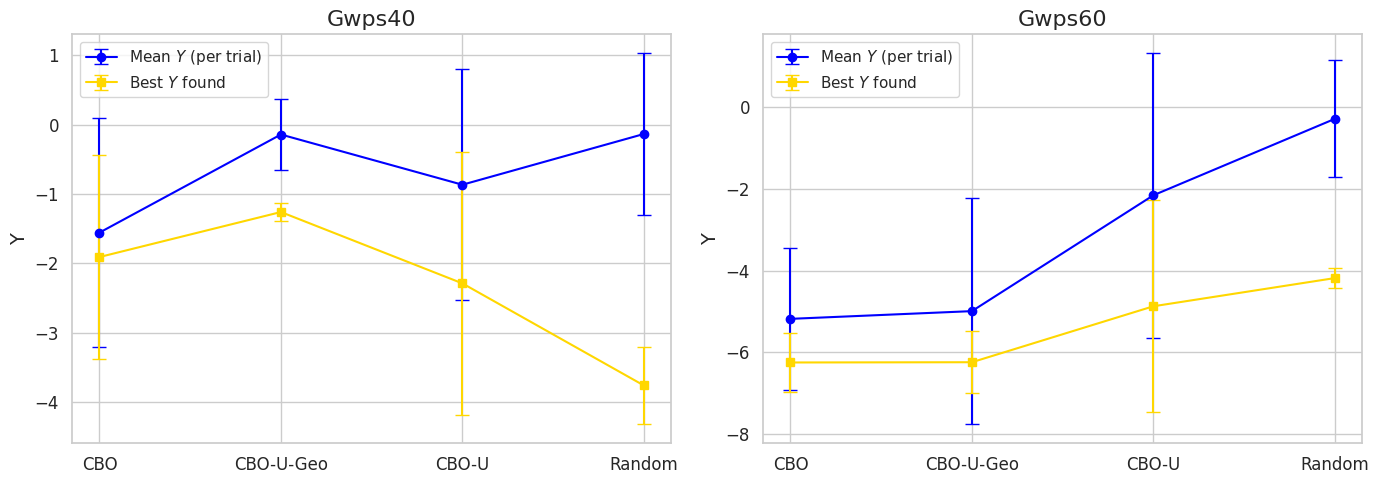

In [3]:
import os

# mean value = mean of Per_trial_Y pooled across all runs/trials (as all_means does)
def mean_value(base, regex):
    if not os.path.isdir(base):
        return np.nan, 0.0
    results = load_results(base, regex)
    if not results:
        return np.nan, 0.0
    pooled = np.hstack([r["Per_trial_Y"] for r in results])
    return pooled.mean(), pooled.std()


# best value = final Best_Y, averaged over the seeds. Note the error bars differ
# in meaning from mean_value's: this one is spread ACROSS seeds, that one is
# spread across pooled trials within runs.
def best_value(base, regex):
    if not os.path.isdir(base):
        return np.nan, 0.0
    results = load_results(base, regex)
    if not results:
        return np.nan, 0.0
    best = np.array([r["Best_Y"][-1] for r in results], dtype=float)
    return best.mean(), best.std()


def summarise():
    method_labels = ["CBO", "CBO-U-Geo", "CBO-U", "Random"]
    fig, axs = plt.subplots(1, len(GRAPHS), figsize=(7 * len(GRAPHS), 5))
    for c, graph in enumerate(GRAPHS):
        specs = [
            (f"../results/{graph}", method_regex("cbo_results", graph)),
            geom_source(graph),
            (f"../results/{graph}", method_regex("cbo_unknown_dr2_results", graph)),
            (f"../results/{graph}", method_regex("cbo_results_random", graph)),
        ]
        means, stds = zip(*[mean_value(b, rx) for b, rx in specs])
        bests, best_stds = zip(*[best_value(b, rx) for b, rx in specs])

        ax = axs[c]
        ax.errorbar(method_labels, means, yerr=stds, marker="o", capsize=5,
                    linestyle="-", color="blue", label="Mean $Y$ (per trial)")
        ax.errorbar(method_labels, bests, yerr=best_stds, marker="s", capsize=5,
                    linestyle="-", color="gold", label="Best $Y$ found")

        ax.tick_params(axis="both", labelsize=12)
        ax.set_title(graph, fontsize=16)
        ax.set_ylabel("Y", fontsize=14)
        ax.legend(fontsize=11)
    _show(fig, "mean_summary")


summarise()

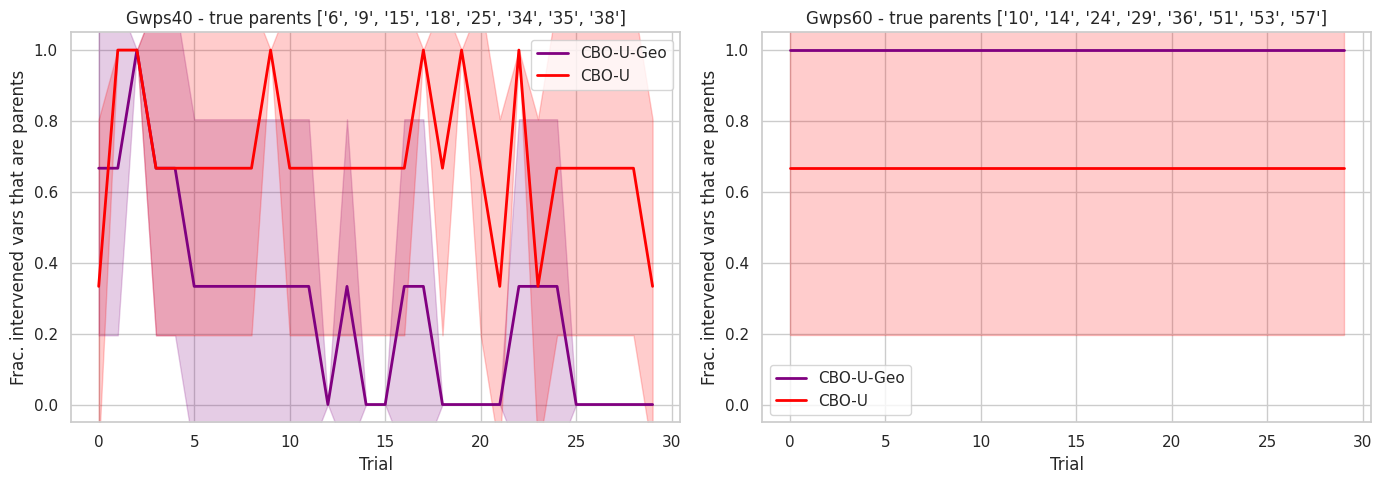

In [4]:
# Parent accuracy per iteration: fraction of the intervened variables that are
# true parents of the target. Compare CBO-U vs CBO-U-Geo, per gwps graph.
# True parents come from the geometry pickle (CBO-U pickles don't store them);
# both pipelines share the same fixed GWPS network per graph size.

def true_parents_for(graph):
    gbase, gregex = geom_source(graph)
    return set(load_results(gbase, gregex)[0]["True_Parents"])


def parent_accuracy(results, true_parents):
    curves = []
    for r in results:
        row = []
        for iv in r["Intervention_Set"]:
            iv = tuple(iv)
            row.append(np.nan if len(iv) == 0
                       else sum(v in true_parents for v in iv) / len(iv))
        curves.append(row)
    return np.array(curves, dtype=float)


def plot_parent_accuracy():
    fig, axes = plt.subplots(1, len(GRAPHS), figsize=(7 * len(GRAPHS), 5))
    for ax, graph in zip(axes, GRAPHS):
        tp = true_parents_for(graph)
        gbase, gregex = geom_source(graph)
        sources = {
            "CBO-U-Geo": (load_results(gbase, gregex), "purple"),
            "CBO-U": (load_results(f"../results/{graph}",
                                   method_regex("cbo_unknown_dr2_results", graph)), "red"),
        }
        for label, (res, color) in sources.items():
            acc = parent_accuracy(res, tp)
            mean, std = np.nanmean(acc, axis=0), np.nanstd(acc, axis=0)
            x = range(len(mean))
            ax.fill_between(x, mean - std, mean + std, alpha=0.2, color=color)
            ax.plot(x, mean, label=label, color=color, linewidth=2)
        ax.set_title(f"{graph} - true parents {sorted(tp, key=int)}")
        ax.set_xlabel("Trial")
        ax.set_ylabel("Frac. intervened vars that are parents")
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True)
        ax.legend()
    _show(fig, "parent_accuracy")


plot_parent_accuracy()

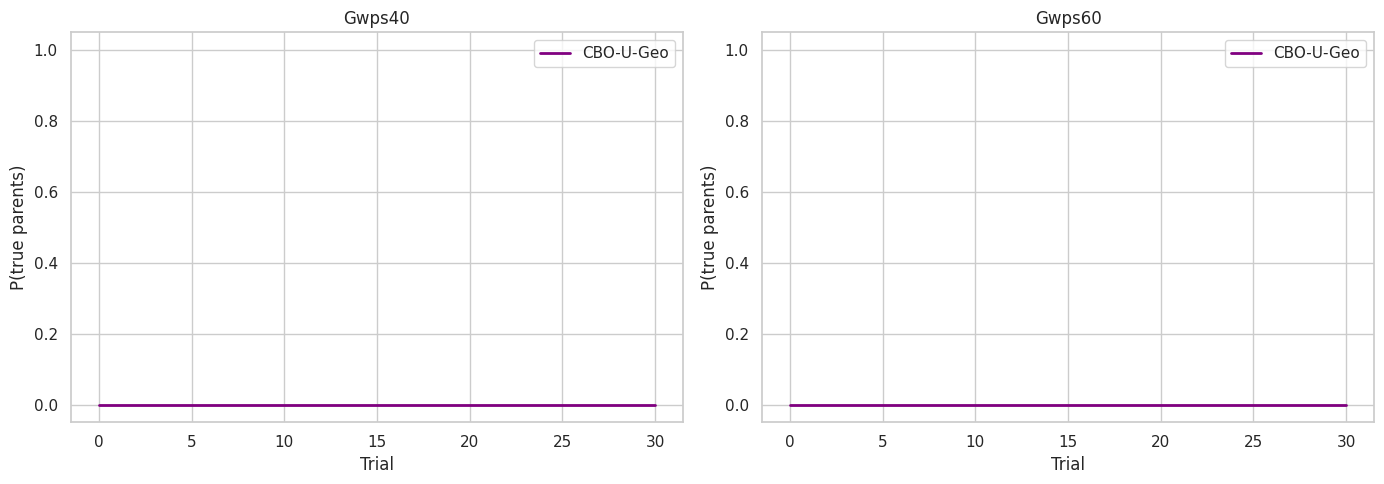

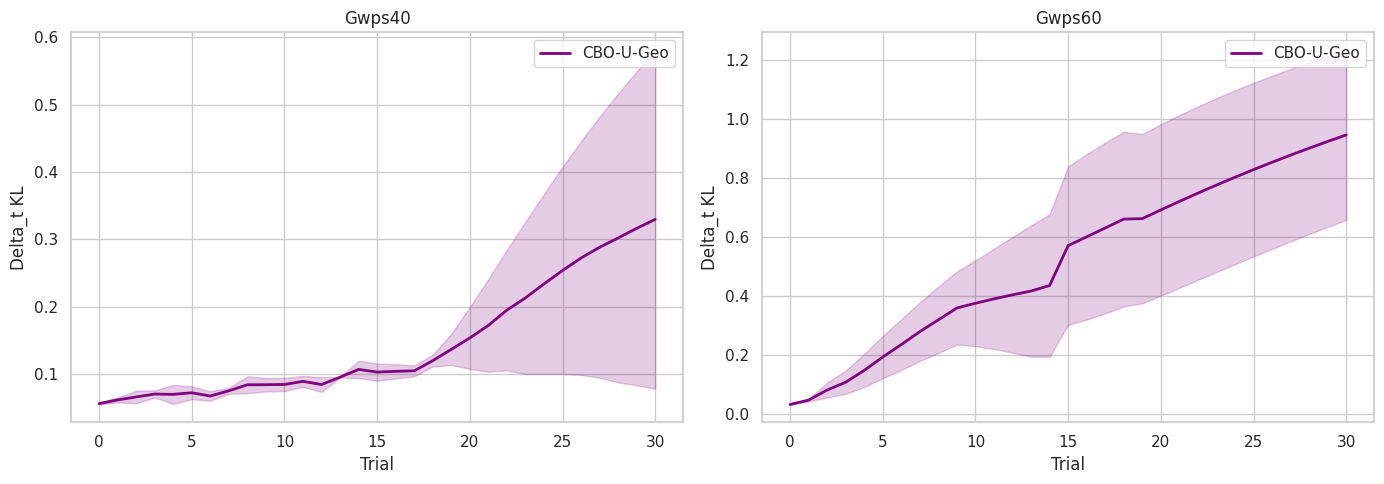

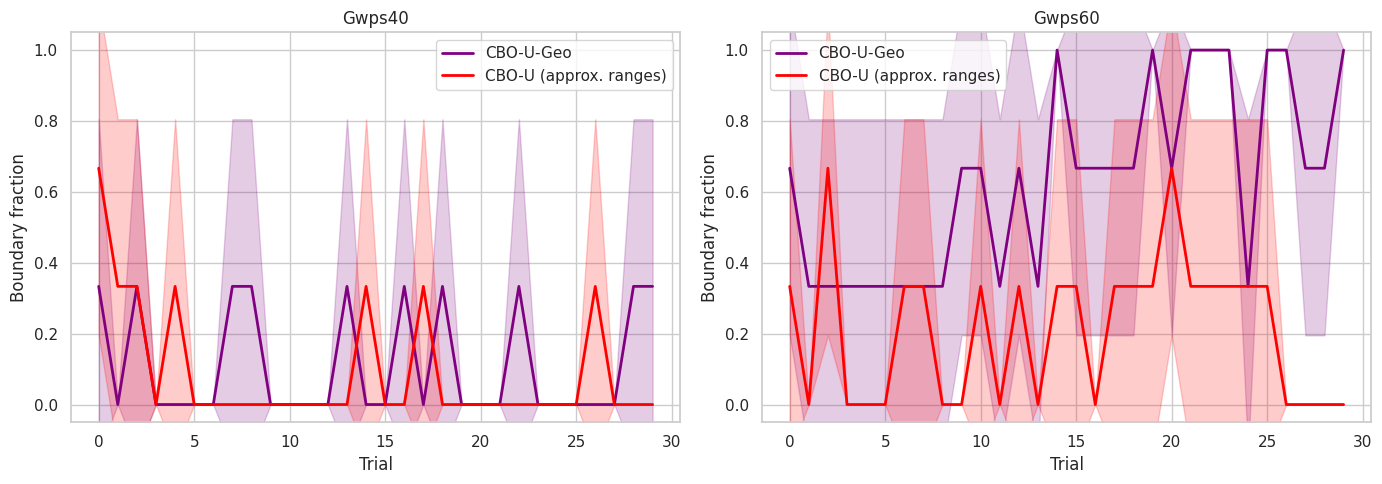

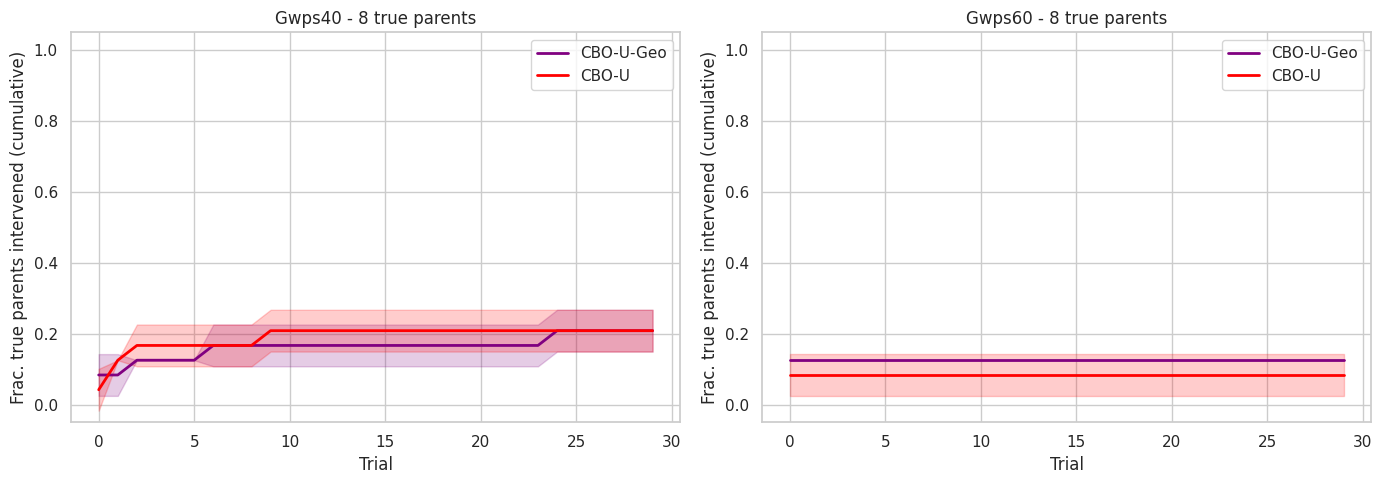

In [5]:
# Extra diagnostics. P_True_Parents / Delta_t_KL are only stored by the geometry
# runs (CBO-U-Geo alone). Coverage and Boundary compare CBO-U vs CBO-U-Geo.
# Unlike erdos, CBO-U here was NOT rerun with the same seed as CBO-U-Geo and its
# pickles store no Intervention_Ranges -- the boundary fraction below (and the
# intervention-position panel further down) approximate CBO-U's ranges with the
# geometry run's box for the same run number (a different observational draw).
import pickle
import re


def _load_by_run(base, regex):
    """[(run_key, result)] -- pairs runs by filename so CBO-U can borrow the
    geometry run with the same run number."""
    if not os.path.isdir(base):
        return []
    out = []
    for f in sorted(f for f in os.listdir(base) if re.match(regex, f)):
        with open(os.path.join(base, f), "rb") as fh:
            out.append((f.split("_")[0], pickle.load(fh)))
    return out


def _geo_runs(graph):
    gbase, gregex = geom_source(graph)
    return [(k, r, r["Intervention_Ranges"]) for k, r in _load_by_run(gbase, gregex)]


def _cbou_runs_with_ranges(graph):
    """CBO-U (gwps) pickles store no intervention ranges -- approximate with the
    geometry run's box for the same run number (a DIFFERENT observational draw)."""
    runs = _load_by_run(f"../results/{graph}", method_regex("cbo_unknown_dr2_results", graph))
    geo_ranges = {k: rng for k, _, rng in _geo_runs(graph)}
    first = next(iter(geo_ranges.values()))
    return [(k, r, geo_ranges.get(k, first)) for k, r in runs]


def geom_series(graph, key):
    gbase, gregex = geom_source(graph)
    data = np.array([r[key] for r in load_results(gbase, gregex)], dtype=float)
    return data.mean(0), data.std(0)


def plot_geom_metric(key, ylabel, ylim=None):
    fig, axes = plt.subplots(1, len(GRAPHS), figsize=(7 * len(GRAPHS), 5))
    for ax, graph in zip(axes, GRAPHS):
        mean, std = geom_series(graph, key)
        x = range(len(mean))
        ax.fill_between(x, mean - std, mean + std, alpha=0.2, color="purple")
        ax.plot(x, mean, label="CBO-U-Geo", color="purple", linewidth=2)
        ax.set_title(graph)
        ax.set_xlabel("Trial")
        ax.set_ylabel(ylabel)
        if ylim:
            ax.set_ylim(*ylim)
        ax.grid(True)
        ax.legend()
    _show(fig, key)


def coverage(results, true_parents):
    tp = set(true_parents)
    curves = []
    for r in results:
        seen, row = set(), []
        for iv in r["Intervention_Set"]:
            seen |= set(iv) & tp
            row.append(len(seen) / len(tp))
        curves.append(row)
    return np.array(curves, dtype=float)


def plot_coverage():
    fig, axes = plt.subplots(1, len(GRAPHS), figsize=(7 * len(GRAPHS), 5))
    for ax, graph in zip(axes, GRAPHS):
        tp = true_parents_for(graph)
        gbase, gregex = geom_source(graph)
        sources = {
            "CBO-U-Geo": (load_results(gbase, gregex), "purple"),
            "CBO-U": (load_results(f"../results/{graph}",
                                   method_regex("cbo_unknown_dr2_results", graph)), "red"),
        }
        for label, (res, color) in sources.items():
            cov = coverage(res, tp)
            mean, std = cov.mean(0), cov.std(0)
            x = range(len(mean))
            ax.fill_between(x, mean - std, mean + std, alpha=0.2, color=color)
            ax.plot(x, mean, label=label, color=color, linewidth=2)
        ax.set_title(f"{graph} - {len(tp)} true parents")
        ax.set_xlabel("Trial")
        ax.set_ylabel("Frac. true parents intervened (cumulative)")
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True)
        ax.legend()
    _show(fig, "coverage")


def cbou_boundary_curve(graph):
    """Boundary fraction per trial for CBO-U, using the (approximate) ranges
    from _cbou_runs_with_ranges and the same formula the geometry pipeline uses
    for Boundary_Percentage."""
    trajs = []
    for _, r, ranges in _cbou_runs_with_ranges(graph):
        traj = []
        for iv_set, iv_val in zip(r["Intervention_Set"], r["Intervention_Value"]):
            n_on = 0
            for var, val in zip(tuple(iv_set), np.ravel(iv_val)):
                lo, hi = ranges[str(var)]
                eps = EPS_FRAC * (hi - lo)
                n_on += val <= lo + eps or val >= hi - eps
            traj.append(n_on / len(tuple(iv_set)))
        trajs.append(traj)
    arr = np.array(trajs, dtype=float)
    return arr.mean(0), arr.std(0)


def plot_boundary():
    fig, axes = plt.subplots(1, len(GRAPHS), figsize=(7 * len(GRAPHS), 5))
    for ax, graph in zip(axes, GRAPHS):
        gmean, gstd = geom_series(graph, "Boundary_Percentage")
        x = range(len(gmean))
        ax.fill_between(x, gmean - gstd, gmean + gstd, alpha=0.2, color="purple")
        ax.plot(x, gmean, label="CBO-U-Geo", color="purple", linewidth=2)

        cmean, cstd = cbou_boundary_curve(graph)
        x = range(len(cmean))
        ax.fill_between(x, cmean - cstd, cmean + cstd, alpha=0.2, color="red")
        ax.plot(x, cmean, label="CBO-U (approx. ranges)", color="red", linewidth=2)

        ax.set_title(graph)
        ax.set_xlabel("Trial")
        ax.set_ylabel("Boundary fraction")
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True)
        ax.legend()
    _show(fig, "Boundary_Percentage")


plot_geom_metric("P_True_Parents", "P(true parents)", ylim=(-0.05, 1.05))
plot_geom_metric("Delta_t_KL", "Delta_t KL")
plot_boundary()
plot_coverage()

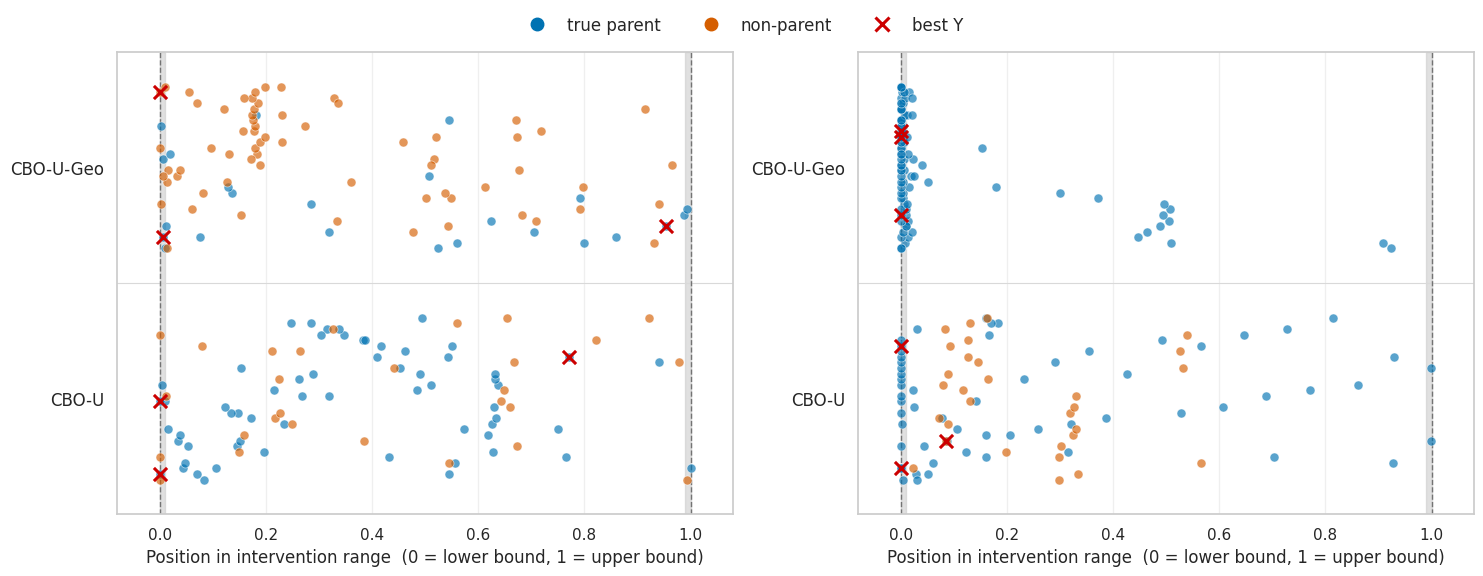

In [7]:
# Where do the interventions actually land? One row per method; every proposed
# intervention is normalised to [0, 1] within its own variable's intervention
# range, pooled over all variables and seeds. Colour says whether the variable
# intervened on is a TRUE PARENT of the target or not. Within a row the vertical
# offset is the trial index (bottom = first trial, top = last), so drift towards
# an edge over a run is visible. The shaded strips at each end are the
# eps = EPS_FRAC collar that Boundary_Percentage counts as "on boundary". CBO-U
# points use the same (approximate) geometry-run ranges as cbou_boundary_curve
# above, hence the panel annotation. A red X marks the intervention from each
# run's best trial (lowest Per_trial_Y -- this is a minimisation task, and
# Best_Y is the running minimum, so argmin(Per_trial_Y) is where Best_Y is set).

PARENT_COLOR, NONPARENT_COLOR = "#0072B2", "#D55E00"   # colourblind-safe pair
BEST_COLOR = "#CC0000"
ROW_ORDER = ["CBO-U", "CBO-U-Geo"]                     # bottom to top


def _points(runs, true_parents):
    """[(normalised value, trial fraction, is_parent)] pooled over runs/variables,
    plus the points from each run's best (lowest Per_trial_Y) trial."""
    pts, best_pts = [], []
    for _, r, ranges in runs:
        n = len(r["Intervention_Set"])
        best_t = int(np.argmin(r["Per_trial_Y"]))
        for t, (iv_set, iv_val) in enumerate(zip(r["Intervention_Set"], r["Intervention_Value"])):
            for var, val in zip(tuple(iv_set), np.ravel(iv_val)):
                lo, hi = ranges[str(var)]
                x, y = (float(val) - lo) / (hi - lo), t / max(n - 1, 1)
                pts.append((x, y, str(var) in true_parents))
                if t == best_t:
                    best_pts.append((x, y))
    return pts, best_pts


def _panel(ax, graph):
    tp = true_parents_for(graph)
    by_method = {
        "CBO-U-Geo": _points(_geo_runs(graph), tp),
        "CBO-U": _points(_cbou_runs_with_ranges(graph), tp),
    }

    for i, method in enumerate(ROW_ORDER):
        pts, best_pts = by_method[method]
        for is_parent, color, label in ((True, PARENT_COLOR, "true parent"),
                                        (False, NONPARENT_COLOR, "non-parent")):
            sel = [p for p in pts if p[2] is is_parent]
            if not sel:
                continue
            seen = ax.get_legend_handles_labels()[1]
            ax.scatter([p[0] for p in sel], [i + 0.15 + 0.70 * p[1] for p in sel],
                       s=42, color=color, alpha=0.65, linewidths=0.5,
                       edgecolors="white", zorder=3,
                       label=label if label not in seen else None)
        if best_pts:
            seen = ax.get_legend_handles_labels()[1]
            ax.scatter([p[0] for p in best_pts], [i + 0.15 + 0.70 * p[1] for p in best_pts],
                       marker="x", s=90, color=BEST_COLOR, linewidths=2.2, zorder=4,
                       label="best Y" if "best Y" not in seen else None)
        if i:
            ax.axhline(i, color="0.85", linewidth=0.8, zorder=1)

    ax.axvspan(0, EPS_FRAC, color="0.80", alpha=0.6, zorder=0)
    ax.axvspan(1 - EPS_FRAC, 1, color="0.80", alpha=0.6, zorder=0)
    for edge in (0.0, 1.0):
        ax.axvline(edge, color="0.45", linestyle="--", linewidth=1, zorder=2)

    ax.set_yticks([i + 0.5 for i in range(len(ROW_ORDER))])
    ax.set_yticklabels(ROW_ORDER, fontsize=12)
    ax.set_ylim(0, len(ROW_ORDER))
    ax.set_xlim(-0.08, 1.08)
    ax.set_xlabel("Position in intervention range  (0 = lower bound, 1 = upper bound)")
    ax.grid(True, axis="x", alpha=0.3)
    ax.grid(False, axis="y")


def plot_intervention_positions():
    fig, axes = plt.subplots(1, len(GRAPHS), figsize=(15, 5.5))
    for ax, graph in zip(axes, GRAPHS):
        _panel(ax, graph)
    # explicit handles: a panel with no non-parent interventions would
    # otherwise silently drop that entry from the legend
    handles = [plt.Line2D([], [], marker="o", linestyle="none", markersize=9,
                          color=c, label=l)
               for c, l in ((PARENT_COLOR, "true parent"),
                            (NONPARENT_COLOR, "non-parent"))]
    handles.append(plt.Line2D([], [], marker="x", linestyle="none", markersize=10,
                              markeredgewidth=2.2, color=BEST_COLOR, label="best Y"))
    fig.legend(handles=handles, loc="upper center", ncol=3, fontsize=12,
               frameon=False, bbox_to_anchor=(0.5, 1.06))
    _show(fig, "intervention_positions")


plot_intervention_positions()